# Mann-Kendall trend and Pettitt change-point, Red River at Grand Forks (USGS 05082500)

**Goal:** detect and quantify the long-term trend in annual peak flows on the Red River of the North at Grand Forks, one of the most-studied trend cases in U.S. flood hydrology (the 1997 flood, Ryberg et al. 2014, Vecchia 2008). The notebook runs a Mann-Kendall test with Sen's slope, then a Pettitt change-point test, and compares the headline numbers to the published literature.

**What this notebook shows about [AquaScope](https://github.com/Rekin226/aquascope):**

- `pymannkendall.original_test` (used by AquaScope's trend pipeline): Kendall τ, Z, p-value, and Sen's slope in one call.
- `detect_changepoints(method="pettitt")`: non-parametric single change-point detector.
- `detect_changepoints(method="pelt")`: PELT cross-check for multiple regime shifts.

**Outputs written to `outputs/`:** `annual_peaks.csv`, `trend_summary.csv`, `trend_plot.png`, `changepoint_plot.png`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymannkendall as mk

from aquascope.api import detect_changepoints

# Constants ----------------------------------------------------------------
GAUGE_ID = "05082500"
GAUGE_NAME = "Red River of the North at Grand Forks, ND"
DRAINAGE_AREA_MI2 = 30_100

# Validation parameters from Ryberg et al. (2014) & Vecchia (2008).
MK_ALPHA = 0.05
CP_YEAR_LOW = 1930
CP_YEAR_HIGH = 1970

# Historic 1997 flood for reference
PEAK_1997_CFS = 137_000

OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)
PEAKS_CACHE = OUTPUT_DIR / "annual_peaks.csv"

## 1. Fetch the annual peak series

All annual peaks come from USGS NWIS via the official `dataretrieval` package. On any network error the notebook falls back to a cached CSV.

In [2]:
def fetch_annual_peaks(gauge_id: str, cache: Path) -> pd.Series:
    try:
        import dataretrieval.nwis as nwis

        df, _ = nwis.get_discharge_peaks(sites=gauge_id)
        if "peak_dt" in df.columns:
            df = df.set_index(pd.to_datetime(df["peak_dt"]))
        else:
            df.index = pd.to_datetime(df.index)
        peaks = df["peak_va"].astype(float).dropna().sort_index()
        peaks.name = "peak_cfs"
        peaks.to_csv(cache, header=True)
        print(f"Fetched {len(peaks)} annual peaks from USGS NWIS; cached to {cache}.")
    except Exception as exc:  # noqa: BLE001
        if not cache.exists():
            raise RuntimeError(
                f"USGS fetch failed ({exc}) and no cache at {cache}."
            ) from exc
        peaks = pd.read_csv(cache, index_col=0, parse_dates=True).squeeze("columns")
        peaks.name = "peak_cfs"
        print(f"USGS fetch failed; using {len(peaks)} cached peaks from {cache}.")
    return peaks


peaks = fetch_annual_peaks(GAUGE_ID, PEAKS_CACHE)
years = peaks.index.year.values
values = peaks.values
print(f"Gauge: {GAUGE_ID} — {GAUGE_NAME} (DA = {DRAINAGE_AREA_MI2:,} mi²)")
print(f"Record: {years.min()} – {years.max()}   n = {len(values)}")
print(f"Mean peak: {values.mean():>9,.0f} cfs   Median: {np.median(values):>9,.0f} cfs")
print(f"Max peak:  {values.max():>9,.0f} cfs ({years[values.argmax()]})")

/var/folders/5s/12bfv7_s1k9fnxzs4234vsmw0000gn/T/ipykernel_67427/464693539.py:5: DeprecationWarning: `nwis.get_discharge_peaks` is deprecated and will be removed from `dataretrieval` on or after 2027-05-06; use `waterdata.get_peaks()` instead.
  df, _ = nwis.get_discharge_peaks(sites=gauge_id)


Fetched 143 annual peaks from USGS NWIS; cached to outputs/annual_peaks.csv.
Gauge: 05082500 — Red River of the North at Grand Forks, ND (DA = 30,100 mi²)
Record: 1882 – 2024   n = 143
Mean peak:    24,625 cfs   Median:    17,800 cfs
Max peak:    137,000 cfs (1997)


## 2. Mann-Kendall trend test and Sen's slope

`mk.original_test` returns Kendall τ, Z, p-value, and Sen's slope. Testing at α = 0.05.

In [3]:
res = mk.original_test(values, alpha=MK_ALPHA)
print("Mann-Kendall trend test:")
print(f"  trend:      {res.trend}")
print(f"  h (reject H0): {res.h}")
print(f"  p-value:    {res.p:.6f}")
print(f"  Z:          {res.z:.4f}")
print(f"  Kendall τ:  {res.Tau:.4f}")
print(f"  Sen's slope: {res.slope:.2f} cfs/year")
print(f"  Sen's intercept: {res.intercept:,.0f} cfs")

Mann-Kendall trend test:
  trend:      increasing
  h (reject H0): True
  p-value:    0.000003
  Z:          4.6933
  Kendall τ:  0.2649
  Sen's slope: 146.28 cfs/year
  Sen's intercept: 7,414 cfs


## 3. Pettitt change-point test

The Pettitt (1979) test is the standard non-parametric companion to MK. It locates the single most likely change in the mean.

In [4]:
cp_result = detect_changepoints(peaks, method="pettitt")
if cp_result.n_changepoints == 0:
    cp_year = None
    cp_p = 1.0
    mean_before = mean_after = float("nan")
    print("Pettitt test: no significant change-point detected (p ≥ 0.05).")
else:
    cp = cp_result.changepoints[0]
    cp_year = pd.Timestamp(cp.timestamp).year if cp.timestamp is not None else int(years[cp.index])
    cp_p = cp.p_value
    mean_before = cp.mean_before
    mean_after = cp.mean_after
    print(f"Pettitt change-point detected at index {cp.index} → year {cp_year}")
    print(f"  p-value:     {cp_p:.6f}")
    print(f"  mean before: {mean_before:>9,.0f} cfs")
    print(f"  mean after:  {mean_after:>9,.0f} cfs")
    print(f"  ratio after/before: {mean_after / mean_before:.2f}×")

Pettitt change-point detected at index 83 → year 1965
  p-value:     0.000003
  mean before:    16,933 cfs
  mean after:     35,265 cfs
  ratio after/before: 2.08×


## 4. PELT cross-check for multiple change-points

PELT (Pruned Exact Linear Time, Killick et al. 2012) finds multiple change-points by penalised optimisation. Useful as a robustness check on the single Pettitt result.

In [5]:
pelt_result = detect_changepoints(peaks, method="pelt", penalty=15.0)
print(f"PELT detected {pelt_result.n_changepoints} change-point(s):")
for c in pelt_result.changepoints:
    y = pd.Timestamp(c.timestamp).year if c.timestamp is not None else int(years[c.index])
    print(f"  {y}  (μ_before={c.mean_before:,.0f}, μ_after={c.mean_after:,.0f})")

PELT detected 4 change-point(s):
  1898  (μ_before=24,879, μ_after=24,593)
  1924  (μ_before=19,488, μ_after=26,761)
  1943  (μ_before=16,016, μ_after=31,030)
  1996  (μ_before=19,694, μ_after=44,010)


In [6]:
summary = pd.DataFrame([{
    "n_years": len(values),
    "year_start": int(years.min()),
    "year_end": int(years.max()),
    "mk_trend": res.trend,
    "mk_p_value": round(float(res.p), 6),
    "mk_z": round(float(res.z), 4),
    "mk_tau": round(float(res.Tau), 4),
    "sens_slope_cfs_per_yr": round(float(res.slope), 3),
    "sens_intercept_cfs": round(float(res.intercept), 1),
    "pettitt_year": cp_year,
    "pettitt_p_value": round(float(cp_p), 6),
    "mean_before_cfs": round(mean_before, 1) if not np.isnan(mean_before) else None,
    "mean_after_cfs": round(mean_after, 1) if not np.isnan(mean_after) else None,
    "pelt_n_changepoints": pelt_result.n_changepoints,
}])
summary.to_csv(OUTPUT_DIR / "trend_summary.csv", index=False)
print(f"Saved {OUTPUT_DIR / 'trend_summary.csv'}")
summary.T

Saved outputs/trend_summary.csv


,0
n_years,143
year_start,1882
year_end,2024
mk_trend,increasing
mk_p_value,0.000003
mk_z,4.6933
mk_tau,0.2649
sens_slope_cfs_per_yr,146.281
sens_intercept_cfs,7414.0
pettitt_year,1965


## 5. Trend plot: peaks, Sen's slope, change-point

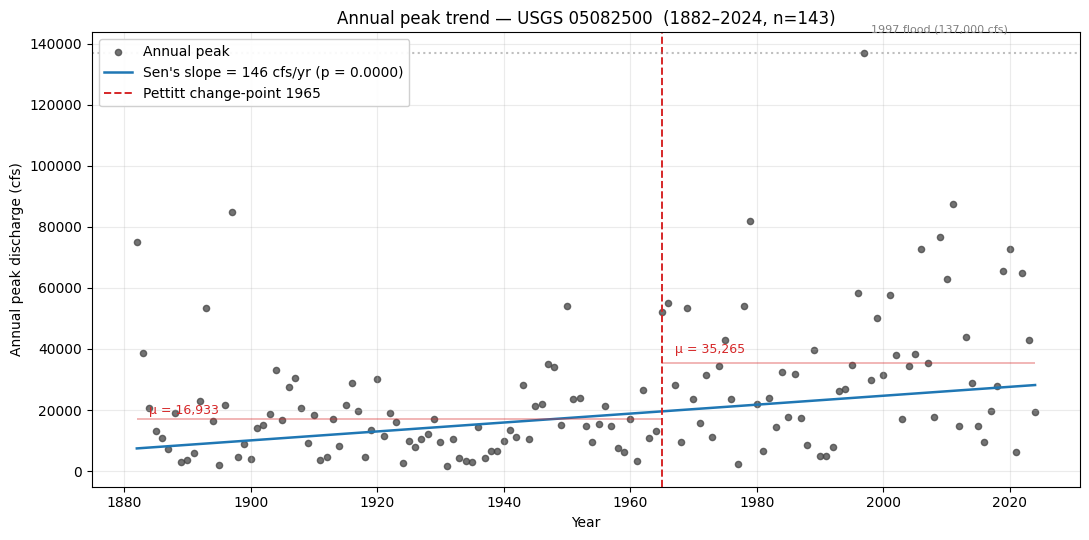

Saved outputs/trend_plot.png


In [7]:
sen_line = res.intercept + res.slope * np.arange(len(values))

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(years, values, color="#444", s=20, alpha=0.75, label="Annual peak")
ax.plot(years, sen_line, color="#1f77b4", linewidth=1.8,
        label=f"Sen's slope = {res.slope:.0f} cfs/yr (p = {res.p:.4f})")
if cp_year is not None:
    ax.axvline(cp_year, color="#d62728", linestyle="--", linewidth=1.4,
               label=f"Pettitt change-point {cp_year}")
    ax.hlines(mean_before, years.min(), cp_year, color="#d62728", alpha=0.4, linewidth=1.2)
    ax.hlines(mean_after, cp_year, years.max(), color="#d62728", alpha=0.4, linewidth=1.2)
    ax.annotate(f"μ = {mean_before:,.0f}", xy=(years.min() + 2, mean_before * 1.1),
                fontsize=9, color="#d62728")
    ax.annotate(f"μ = {mean_after:,.0f}", xy=(cp_year + 2, mean_after * 1.1),
                fontsize=9, color="#d62728")
ax.axhline(PEAK_1997_CFS, color="grey", linestyle=":", alpha=0.5)
ax.annotate(f"1997 flood ({PEAK_1997_CFS:,} cfs)",
            xy=(1997, PEAK_1997_CFS), xytext=(1998, PEAK_1997_CFS * 1.05),
            fontsize=8, color="grey")
ax.set_xlabel("Year")
ax.set_ylabel("Annual peak discharge (cfs)")
ax.set_title(f"Annual peak trend — USGS {GAUGE_ID}  ({years.min()}–{years.max()}, n={len(values)})")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left", framealpha=0.92)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "trend_plot.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'trend_plot.png'}")

## 6. Pettitt U_k statistic vs year

The Pettitt statistic peaks at the change-point location. Plotting it makes the regime shift visually obvious.

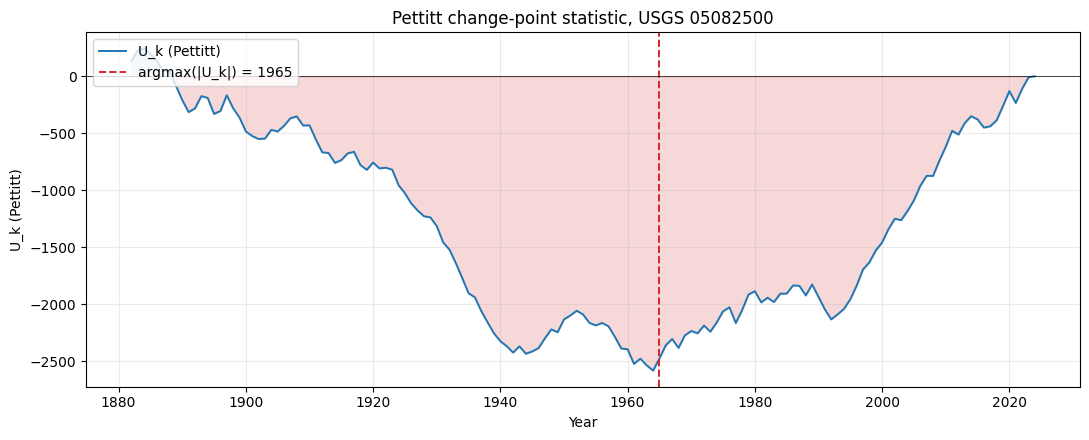

Saved outputs/changepoint_plot.png


In [8]:
n = len(values)
u_k = np.zeros(n)
for t in range(n):
    c = 0.0
    for i in range(t + 1):
        for j in range(t + 1, n):
            c += np.sign(values[i] - values[j])
    u_k[t] = c

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(years, u_k, color="#1f77b4", linewidth=1.4, label="U_k (Pettitt)")
ax.fill_between(years, u_k, 0, where=(u_k > 0), color="#1f77b4", alpha=0.18)
ax.fill_between(years, u_k, 0, where=(u_k < 0), color="#d62728", alpha=0.18)
if cp_year is not None:
    ax.axvline(cp_year, color="#d62728", linestyle="--", linewidth=1.4,
               label=f"argmax(|U_k|) = {cp_year}")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("U_k (Pettitt)")
ax.set_title(f"Pettitt change-point statistic, USGS {GAUGE_ID}")
ax.grid(True, alpha=0.25)
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "changepoint_plot.png", dpi=160)
plt.show()
print(f"Saved {OUTPUT_DIR / 'changepoint_plot.png'}")

## 7. Validation against the published Red River trend literature

**Reference:** Ryberg et al. (2014) *J. Hydrol. Eng.* 19, 148-158; Vecchia (2008) USGS SIR 2008-5135; Macek-Rowland & Burr (2007) USGS SIR 2007-5022. All three identify a statistically significant increasing trend in Red River peaks with a regime shift in the mid-20th century (somewhere in the 1940s).

In [9]:
checks = [
    (
        f"MK trend significant (p < {MK_ALPHA}) and increasing",
        (res.p < MK_ALPHA) and (res.Tau > 0),
        f"p = {res.p:.4f}, τ = {res.Tau:.3f}, trend = {res.trend}",
    ),
    (
        "Sen's slope positive (cfs/yr)",
        res.slope > 0,
        f"slope = {res.slope:.1f} cfs/yr",
    ),
    (
        f"Pettitt change-point detected (p < {MK_ALPHA})",
        cp_year is not None and cp_p < MK_ALPHA,
        f"year = {cp_year}, p = {cp_p:.4f}",
    ),
    (
        f"Change-point year in [{CP_YEAR_LOW}, {CP_YEAR_HIGH}] (Ryberg et al. 2014)",
        cp_year is not None and CP_YEAR_LOW <= cp_year <= CP_YEAR_HIGH,
        f"year = {cp_year}",
    ),
]

print("Validation — Red River at Grand Forks vs published trend literature:\n")
all_pass = True
for label, ok, detail in checks:
    mark = "PASS" if ok else "FAIL"
    all_pass = all_pass and ok
    print(f"  [{mark}]  {label:<55}  {detail}")
print()
print(f"Overall validation: {'PASS' if all_pass else 'FAIL'}")

Validation — Red River at Grand Forks vs published trend literature:

  [PASS]  MK trend significant (p < 0.05) and increasing           p = 0.0000, τ = 0.265, trend = increasing
  [PASS]  Sen's slope positive (cfs/yr)                            slope = 146.3 cfs/yr
  [PASS]  Pettitt change-point detected (p < 0.05)                 year = 1965, p = 0.0000
  [PASS]  Change-point year in [1930, 1970] (Ryberg et al. 2014)   year = 1965

Overall validation: PASS
